# YOLO11n-OBB: Document Detection Model

**Objective:** Train YOLO11n-OBB untuk mendeteksi letak dokumen tugas mahasiswa dari foto kamera HP. <br>
**Target Deployment:** Cloud Free Tier (1 vCPU, <1GB RAM) via ONNX Runtime. <br>
**Pipeline Position:** Model 1 dalam chain → jika OBB terdeteksi, crop & warp → lanjut ke Model 2 (Classification). <br>

---

### Notebook Structure
1. Environment Setup & Dependency Check
2. Dataset Verification & EDA
3. Training Configuration & Hyperparameter Rationale
4. Training Execution
5. Evaluation & Metrics Analysis
6. ONNX Export (CPU-optimized)
7. ONNX Runtime Inference Pipeline (Production-ready)
8. End-to-End Integration Test

## 1. Environment Setup

In [1]:
import cv2
import yaml
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch
from ultralytics import YOLO, settings

# Enable wandb logging
settings.update({'wandb': True})

# REPRODUCIBILITY SETUP
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# DETECT DEVICE
DEVICE = 0 if torch.cuda.is_available() else 'cpu'
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"Device: {DEVICE}")

PyTorch: 2.11.0+cu130
CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
VRAM: 8.6 GB
Device: 0


## 2. Dataset Verification & EDA

In [2]:
# Dataset Path
DATASET_ROOT = Path("../dataset/final_split/model1_yolo")
YAML_PATH = DATASET_ROOT / "model1_yolo.yaml"

# Validate Dataset
assert YAML_PATH.exists(), f"YAML tidak ditemukan: {YAML_PATH}"

with open(YAML_PATH, 'r') as f:
    dataset_cfg = yaml.safe_load(f)

print("=" * 50)
print("DATASET CONFIGURATION")
print("=" * 50)
for k, v in dataset_cfg.items():
    print(f"  {k}: {v}")

DATASET CONFIGURATION
  path: /home/gradi/projects/MitBridge/dataset/final_split/model1_yolo
  train: images/train
  val: images/val
  test: images/test
  nc: 1
  names: {0: 'document'}


In [3]:
# Dataset Integrity Check

splits = ['train', 'val', 'test']
stats = {}

for split in splits:
    img_dir = DATASET_ROOT / 'images' / split
    lbl_dir = DATASET_ROOT / 'labels' / split

    imgs = set(p.stem for p in img_dir.glob('*') if p.suffix.lower() in ('.jpg', '.jpeg', '.png', '.bmp'))
    lbls = set(p.stem for p in lbl_dir.glob('*.txt'))

    missing_labels = imgs - lbls
    orphan_labels = lbls - imgs

    # Hitung distribusi: positive (ada OBB) vs negative (label kosong)
    n_positive = 0
    n_negative = 0
    n_objects_total = 0

    for stem in imgs & lbls:
        lbl_file = lbl_dir / f"{stem}.txt"
        content = lbl_file.read_text().strip()
        if content == '':
            n_negative += 1
        else:
            lines = content.split('\n')
            n_positive += 1
            n_objects_total += len(lines)

    stats[split] = {
        'images': len(imgs),
        'labels': len(lbls),
        'missing': len(missing_labels),
        'orphan': len(orphan_labels),
        'positive': n_positive,
        'negative': n_negative,
        'total_objects': n_objects_total,
    }

    status = '✅' if len(missing_labels) == 0 and len(orphan_labels) == 0 else '❌'
    print(f"\n{status} [{split.upper()}]")
    print(f"  Images: {len(imgs)} | Labels: {len(lbls)}")
    print(f"  Positive (with OBB): {n_positive} | Negative (background): {n_negative}")
    print(f"  Total objects annotated: {n_objects_total}")
    if missing_labels:
        print(f"  ⚠️ Missing labels: {list(missing_labels)[:5]}...")
    if orphan_labels:
        print(f"  ⚠️ Orphan labels: {list(orphan_labels)[:5]}...")


✅ [TRAIN]
  Images: 3570 | Labels: 3570
  Positive (with OBB): 3150 | Negative (background): 420
  Total objects annotated: 3175

✅ [VAL]
  Images: 765 | Labels: 765
  Positive (with OBB): 675 | Negative (background): 90
  Total objects annotated: 681

✅ [TEST]
  Images: 765 | Labels: 765
  Positive (with OBB): 675 | Negative (background): 90
  Total objects annotated: 676


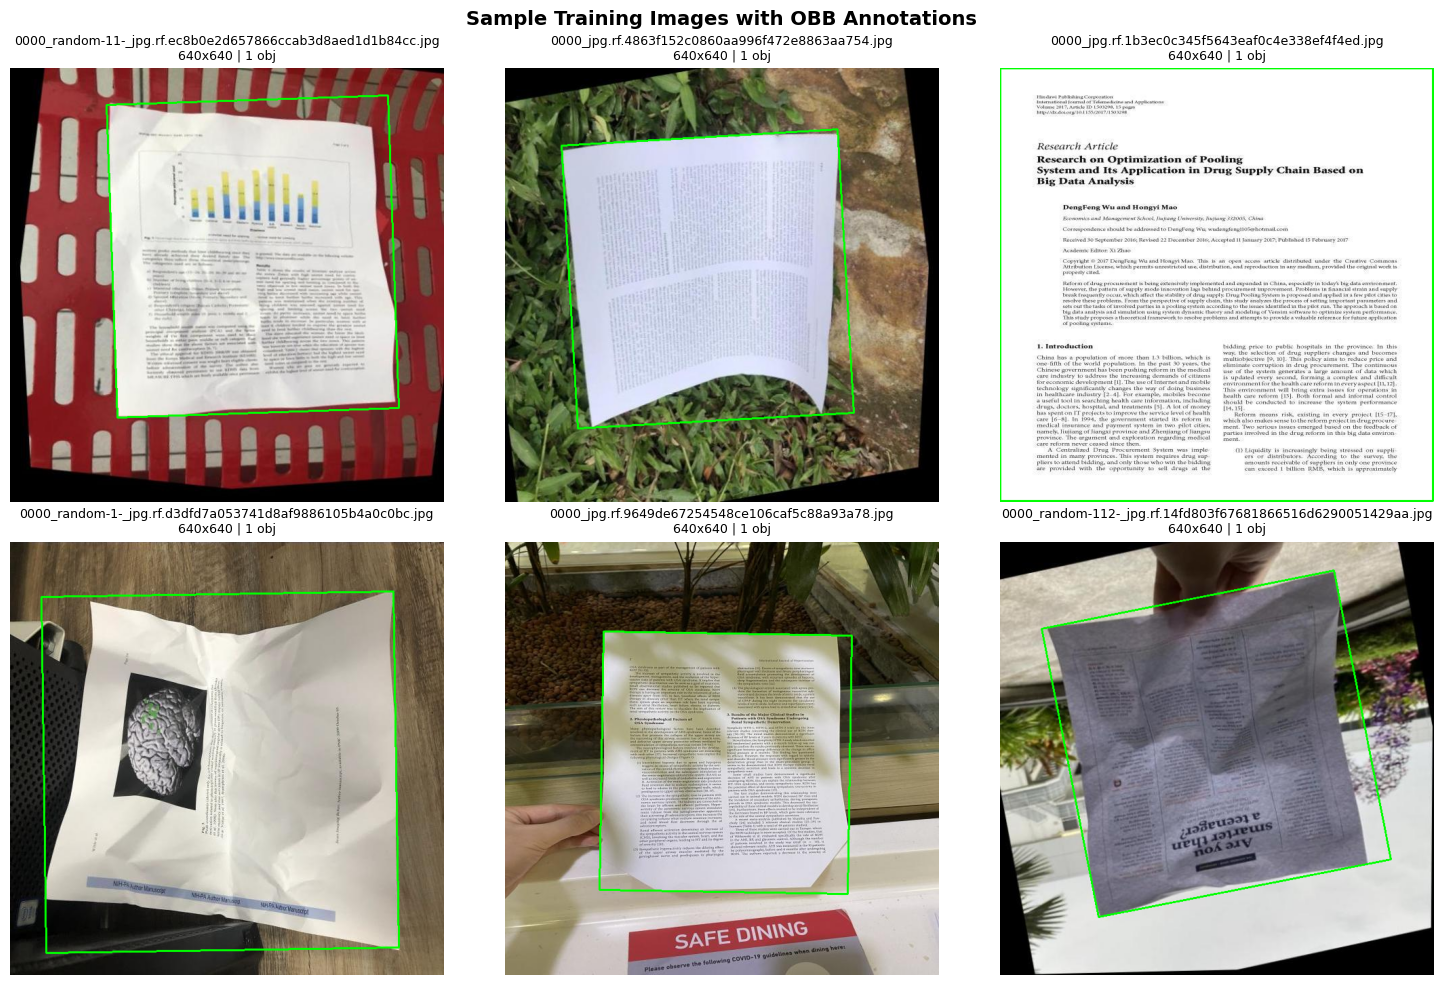

In [4]:
# Sanity Check

def parse_obb_label(label_path):
    """Parse OBB label: class x1 y1 x2 y2 x3 y3 x4 y4 (normalized)"""
    boxes = []
    content = Path(label_path).read_text().strip()
    if not content:
        return boxes
    for line in content.split('\n'):
        parts = line.strip().split()
        if len(parts) == 9:  # class + 4 points (8 coords)
            cls = int(parts[0])
            coords = [float(x) for x in parts[1:]]
            boxes.append((cls, coords))
    return boxes

def draw_obb_on_image(img, boxes):
    """Draw OBB polygons on image"""
    h, w = img.shape[:2]
    vis = img.copy()
    for cls, coords in boxes:
        pts = np.array([
            [coords[0]*w, coords[1]*h],
            [coords[2]*w, coords[3]*h],
            [coords[4]*w, coords[5]*h],
            [coords[6]*w, coords[7]*h],
        ], dtype=np.int32)
        cv2.polylines(vis, [pts], True, (0, 255, 0), 2)
    return vis

# Ambil 6 sampel positive dari train
train_img_dir = DATASET_ROOT / 'images' / 'train'
train_lbl_dir = DATASET_ROOT / 'labels' / 'train'

positive_samples = []
for img_path in sorted(train_img_dir.glob('*')):
    if img_path.suffix.lower() not in ('.jpg', '.jpeg', '.png'):
        continue
    lbl_path = train_lbl_dir / f"{img_path.stem}.txt"
    if lbl_path.exists():
        boxes = parse_obb_label(lbl_path)
        if boxes:
            positive_samples.append((img_path, boxes))
    if len(positive_samples) >= 12:
        break

# Tampilkan
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
selected = random.sample(positive_samples, min(6, len(positive_samples)))

for ax, (img_path, boxes) in zip(axes.flat, selected):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    vis = draw_obb_on_image(img, boxes)
    ax.imshow(vis)
    ax.set_title(f"{img_path.name}\n{img.shape[1]}x{img.shape[0]} | {len(boxes)} obj", fontsize=9)
    ax.axis('off')

plt.suptitle('Sample Training Images with OBB Annotations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [5]:
# Analisis Distribusi Dimensi Gambar

widths, heights = [], []
for img_path in (DATASET_ROOT / 'images' / 'train').glob('*'):
    if img_path.suffix.lower() not in ('.jpg', '.jpeg', '.png'):
        continue
    img = cv2.imread(str(img_path))
    if img is not None:
        h, w = img.shape[:2]
        widths.append(w)
        heights.append(h)

print(f"Image dimensions (train split):")
print(f"  Width  - min: {min(widths)}, max: {max(widths)}, median: {int(np.median(widths))}")
print(f"  Height - min: {min(heights)}, max: {max(heights)}, median: {int(np.median(heights))}")
print(f"  Aspect ratios: {min(w/h for w,h in zip(widths,heights)):.2f} - {max(w/h for w,h in zip(widths,heights)):.2f}")

Image dimensions (train split):
  Width  - min: 200, max: 1920, median: 640
  Height - min: 145, max: 1080, median: 640
  Aspect ratios: 0.38 - 3.30


## 3. Training Configuration

### Hyperparameter Rationale

| Parameter | Value            | Rationale                                                                                     |
|-----------|------------------|-----------------------------------------------------------------------------------------------|
| `model` | `yolo11n-obb.pt` | Pretrained OBB weights. Nano variant → smallest footprint, cocok untuk 1 vCPU deployment      |
| `imgsz` | `640`            | Standard YOLO input. Match dengan inference pipeline yang sudah didesain                      |
| `epochs` | `50`             | Cukup untuk convergence pada ~4800 images. Early stopping `patience=10` akan cut jika plateau |
| `batch` | `-1` (auto)      | Ultralytics auto-batch: otomatis cari batch size maksimal sesuai GPU VRAM                     |
| `optimizer` | `AdamW`          | Lebih stable dari SGD untuk dataset kecil-menengah (ref: Loshchilov & Hutter, 2019)           |
| `lr0` | `0.001`          | Default AdamW LR, proven stable untuk fine-tuning pretrained YOLO                             |
| `lrf` | `0.01`           | Final LR = lr0 * lrf = 1e-5. Cosine decay yang smooth                                         |
| `warmup_epochs` | `3`              | Gentle warmup agar pretrained weights tidak rusak di awal                                     |
| `cos_lr` | `True`           | Cosine annealing > linear decay (ref: Loshchilov & Hutter, SGDR, 2017)                        |
| `patience` | `10`             | Early stopping pada val loss. Aggressive enough to prevent overfit                            |
| `augment` | Built-in         | YOLO default augmentations (mosaic, mixup, hsv, flip, dll.) sudah optimal                     |
| `close_mosaic` | `10`             | Matikan mosaic augment di 10 epoch terakhir → stabilisasi fine-grained learning               |
| `freeze` | `None`           | Full fine-tune. Dataset cukup besar & domain cukup berbeda dari DOTA pretrained               |
| `nms_type` | default          | Rotated NMS bawaan Ultralytics untuk OBB                                                      |

In [6]:
# === Training Configuration ===

import os
os.environ["WANDB_PROJECT"] = "MitBridge" # Set wandb project

MODEL_VARIANT = 'yolo11n-obb.pt'  # Nano OBB pretrained
IMGSZ = 640
EPOCHS = 50
PATIENCE = 10

# Output directory
PROJECT = os.path.join(os.getcwd(), '../runs/model1_yolo')
NAME = 'document_detector'

print(f"Model: {MODEL_VARIANT}")
print(f"Image Size: {IMGSZ}")
print(f"Max Epochs: {EPOCHS} (early stop patience={PATIENCE})")
print(f"Output: {PROJECT}/{NAME}")

Model: yolo11n-obb.pt
Image Size: 640
Max Epochs: 50 (early stop patience=10)
Output: /home/gradi/projects/MitBridge/runs/model1_yolo/document_detector


## 4. Training Execution

In [7]:
# === Load Pretrained Model ===
model = YOLO(MODEL_VARIANT)

# Verifikasi arsitektur
print(f"Model task: {model.task}")
print(f"Model type: {type(model.model).__name__}")

Model task: obb
Model type: OBBModel


In [8]:
# === Start Training ===

results = model.train(
    data=str(YAML_PATH),
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=-1,            # Auto batch size
    device=DEVICE,

    # Optimizer
    optimizer='AdamW',
    lr0=0.001,
    lrf=0.01,            # Final LR ratio (cosine decay target)
    warmup_epochs=3,
    cos_lr=True,
    weight_decay=0.0005,

    # Regularization & Early Stopping
    patience=PATIENCE,
    close_mosaic=10,     # Disable mosaic in last 10 epochs

    # Augmentation (YOLO built-in defaults yang sudah battle-tested)
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=15.0,        # Rotasi ±15° → dokumen bisa miring
    translate=0.1,
    scale=0.5,
    fliplr=0.5,
    flipud=0.0,          # Dokumen jarang terbalik vertikal
    mosaic=1.0,
    mixup=0.1,           # Light mixup untuk regularisasi

    # Output
    project=PROJECT,
    name=NAME,
    exist_ok=True,
    verbose=True,
    plots=True,
    save=True,
    save_period=-1,      # Save only best & last

    # Reproducibility
    seed=SEED,
    deterministic=True,

    # Workers
    workers=0,
)

New https://pypi.org/project/ultralytics/8.4.46 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.41 🚀 Python-3.13.3 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=dataset/final_split/model1_yolo/model1_yolo.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo11n-obb.pt, momentu

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/gradi/.netrc.
wandb: Currently logged in as: gradienridholumintu555306 (gradienridholumintu555306-universitas-gadjah-mada-library) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: setting up run document_detector_20260506_100704
wandb: Tracking run with wandb version 0.26.1
wandb: Run data is saved locally in /home/gradi/projects/MitBridge/runs/model1_yolo/document_detector/wandb/run-20260506_100705-document_detector_20260506_100704
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run document_detector
wandb: ⭐️ View project at https://wandb.ai/gradienridholumintu555306-universitas-gadjah-mada-library/-home-gradi-projects-MitBridge-runs-model1_yolo
wandb: 🚀 View run at https://wandb.ai/gradienridholumintu555306-universitas-gadjah-mada-library/-home-gradi-projects-MitBridge-runs-model1_yolo/runs/document_detector_20260506_100704


Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      6640  ultralytics.nn.modules.block.C3k2            [32, 64, 1, False, 0.25]      
  3                  -1  1     36992  ultralytics.nn.modules.conv.Conv             [64, 64, 3, 2]                
  4                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  5                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  6                  -1  1     87040  ultralytics.nn.modules.block.C3k2            [128, 128, 1, True]           
  7                  -1  1    295424  ultralytics

wandb: WARNING Tried to log to step 50 that is less than the current step 51. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: uploading artifact run_document_detector_20260506_100704_model; updating run metadata; uploading artifact run-document_detector_20260506_100704-curvesPrecision-RecallB_table-6L7aUQ; uploading artifact run-document_detector_20260506_100704-curvesF1-ConfidenceB_table-zXj5Xg; uploading artifact run-document_detector_20260506_100704-curvesPrecision-ConfidenceB_table-1chcQQ (+ 1 more)
wandb: uploading artifact run_document_detector_20260506_100704_model; uploading artifact run-document_detector_20260506_100704-curvesPrecision-RecallB_table-6L7aUQ; uploading artifact run-document_detector_20260506_100704-curvesF1-ConfidenceB_table-zXj5Xg; uploading artifact run-document_detector_20260506_100704-curvesPrecision-ConfidenceB_table-1chcQQ; uploading artifact run-document_detector_202

## 5. Evaluation & Metrics Analysis

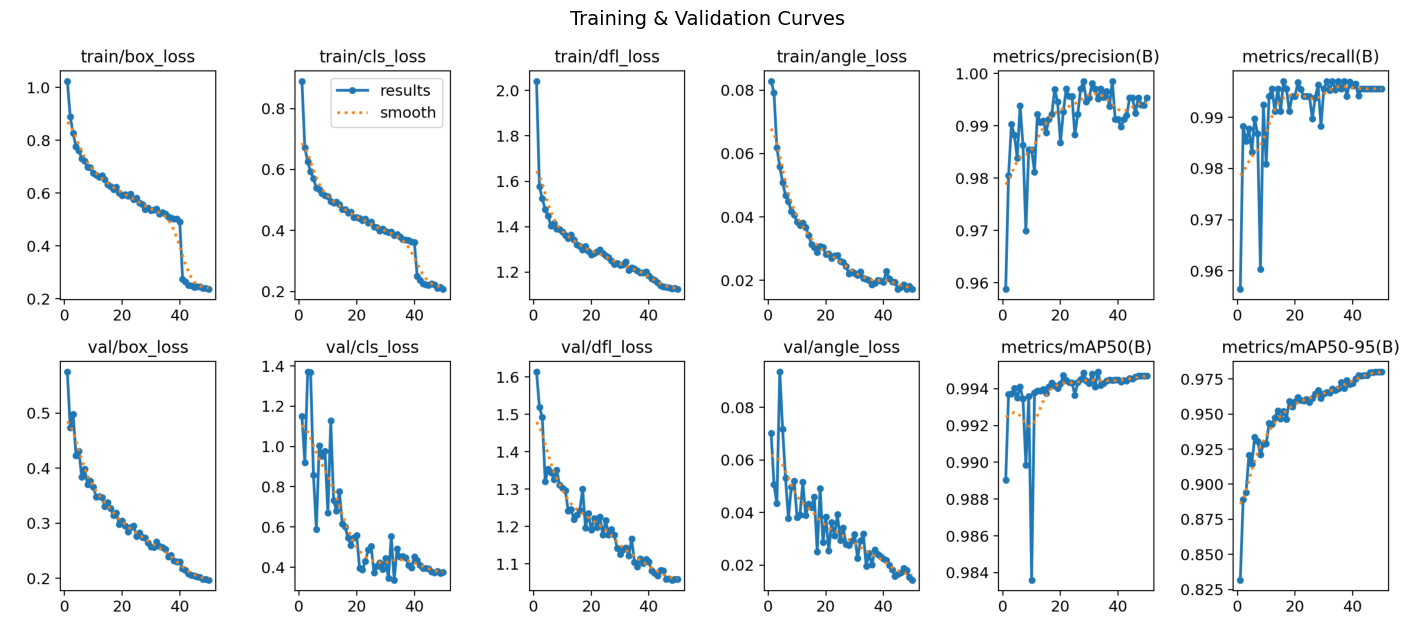

In [9]:
# Training Curves

RESULTS_DIR = Path("../runs/model1_yolo/document_detector")

# Tampilkan training curves
results_png = RESULTS_DIR / 'results.png'
if results_png.exists():
    img = cv2.imread(str(results_png))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(18, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Training & Validation Curves', fontsize=14)
    plt.show()
else:
    print("results.png belum ada, training mungkin belum selesai.")

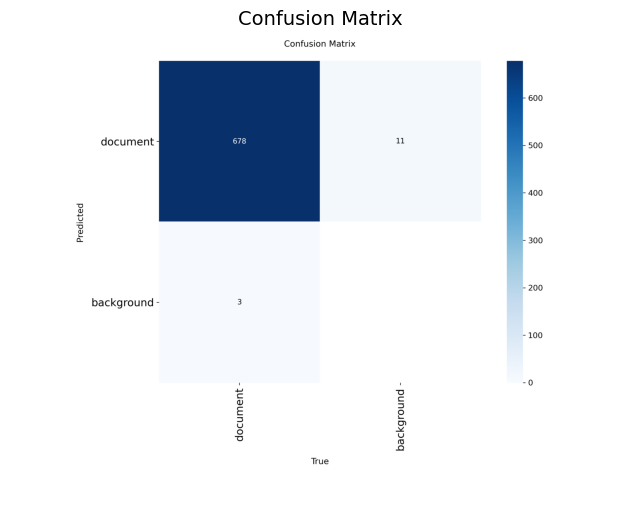

In [10]:
# Confusion Matrix
cm_png = RESULTS_DIR / 'confusion_matrix.png'
if cm_png.exists():
    img = cv2.imread(str(cm_png))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Confusion Matrix', fontsize=14)
    plt.show()

In [11]:
# Validate on Val Set (menggunakan best.pt)

best_pt = RESULTS_DIR / 'weights' / 'best.pt'
assert best_pt.exists(), f"best.pt tidak ditemukan di {best_pt}"

best_model = YOLO(str(best_pt))
val_metrics = best_model.val(
    data=str(YAML_PATH),
    imgsz=IMGSZ,
    batch=16,
    device=DEVICE,
    split='val',
    plots=True,
    verbose=True,
)

print("\n" + "=" * 50)
print("VALIDATION METRICS")
print("=" * 50)
print(f"  mAP50:      {val_metrics.box.map50:.4f}")
print(f"  mAP50-95:   {val_metrics.box.map:.4f}")
print(f"  Precision:  {val_metrics.box.mp:.4f}")
print(f"  Recall:     {val_metrics.box.mr:.4f}")

Ultralytics 8.4.41 🚀 Python-3.13.3 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
YOLO11n-obb summary (fused): 110 layers, 2,653,918 parameters, 0 gradients, 6.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1454.8±809.0 MB/s, size: 53.0 KB)
val: Scanning /home/gradi/projects/MitBridge/dataset/final_split/model1_yolo/labels/val.cache... 765 images, 90 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 765/765 291.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 48/48 3.6it/s 13.4s0.3s
                   all        765        681      0.994      0.996      0.995       0.98
Speed: 1.2ms preprocess, 3.3ms inference, 0.0ms loss, 2.5ms postprocess per image
Results saved to /home/gradi/projects/FAIND/runs/obb/val-19

VALIDATION METRICS
  mAP50:      0.9947
  mAP50-95:   0.9801
  Precision:  0.9940
  Recall:     0.9956


In [12]:
# Validate on Test Set

test_metrics = best_model.val(
    data=str(YAML_PATH),
    imgsz=IMGSZ,
    batch=16,
    device=DEVICE,
    split='test',
    plots=True,
    verbose=True,
)

print("\n" + "=" * 50)
print("TEST METRICS (Hold-out)")
print("=" * 50)
print(f"  mAP50:      {test_metrics.box.map50:.4f}")
print(f"  mAP50-95:   {test_metrics.box.map:.4f}")
print(f"  Precision:  {test_metrics.box.mp:.4f}")
print(f"  Recall:     {test_metrics.box.mr:.4f}")

Ultralytics 8.4.41 🚀 Python-3.13.3 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
val: Fast image access ✅ (ping: 0.1±0.1 ms, read: 81.8±40.0 MB/s, size: 89.4 KB)
val: Scanning /home/gradi/projects/MitBridge/dataset/final_split/model1_yolo/labels/test.cache... 765 images, 90 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 765/765 160.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 48/48 5.8it/s 8.3s0.1s
                   all        765        676      0.997      0.999      0.995       0.98
Speed: 1.2ms preprocess, 2.4ms inference, 0.0ms loss, 2.3ms postprocess per image
Results saved to /home/gradi/projects/FAIND/runs/obb/val-20

TEST METRICS (Hold-out)
  mAP50:      0.9950
  mAP50-95:   0.9802
  Precision:  0.9966
  Recall:     0.9985


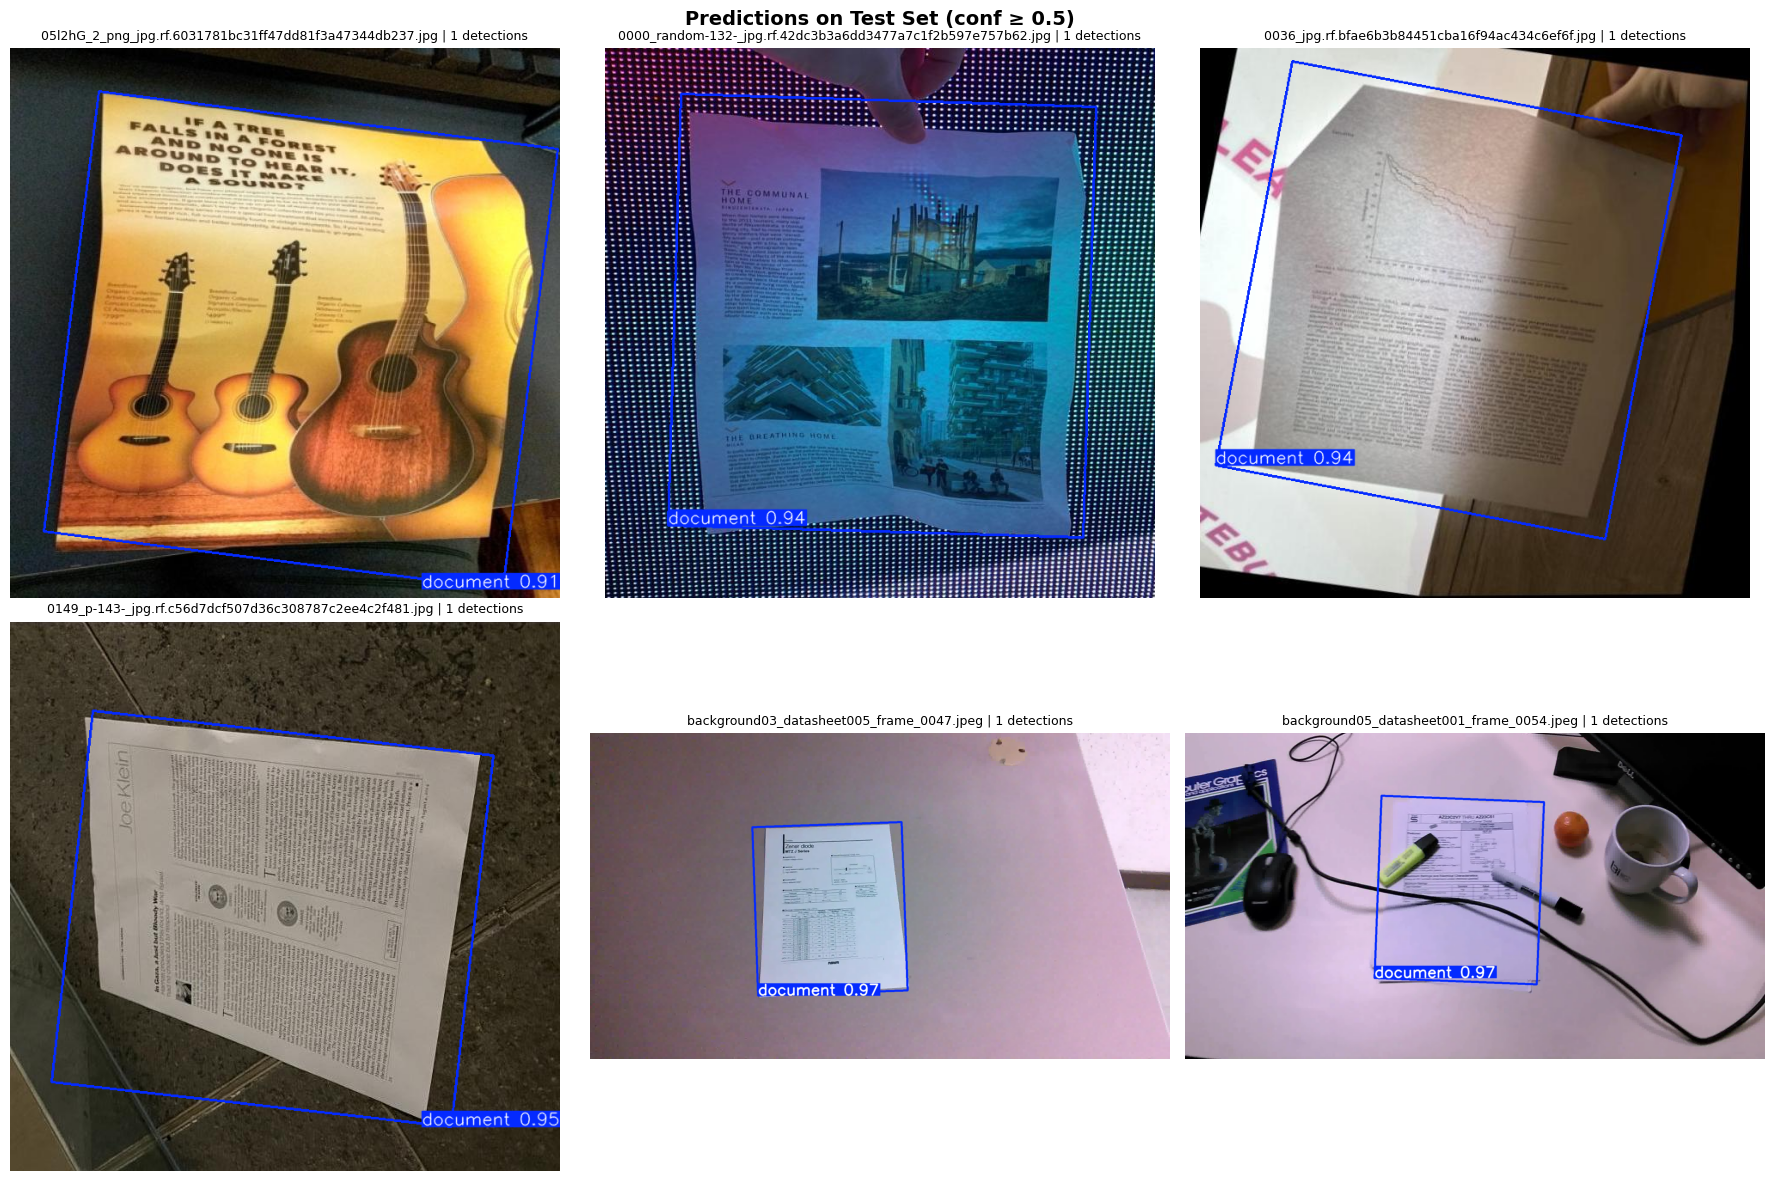

In [13]:
# Visual Prediction Samples on Test Set

test_img_dir = DATASET_ROOT / 'images' / 'test'
test_images = list(test_img_dir.glob('*'))
test_images = [p for p in test_images if p.suffix.lower() in ('.jpg', '.jpeg', '.png')]
sample_images = random.sample(test_images, min(6, len(test_images)))

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for ax, img_path in zip(axes.flat, sample_images):
    results = best_model.predict(
        source=str(img_path),
        imgsz=IMGSZ,
        conf=0.5,
        device=DEVICE,
        verbose=False,
    )
    # Plot dengan OBB
    annotated = results[0].plot()
    annotated = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

    n_det = len(results[0].obb) if results[0].obb is not None else 0
    ax.imshow(annotated)
    ax.set_title(f"{img_path.name} | {n_det} detections", fontsize=9)
    ax.axis('off')

plt.suptitle('Predictions on Test Set (conf ≥ 0.5)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. ONNX Export

### Export Strategy

**Dua opsi export** dipertimbangkan:

| Opsi | Flag | Output Shape | Pro | Con |
|------|------|-------------|-----|-----|
| A | `nms=False` | `(1, 6, 8400)` | Bisa quantize, lebih fleksibel | Perlu custom NMS postprocess |
| B | `nms=True` | `(1, 300, 7)` | NMS sudah embedded, postprocess minimal | Graph lebih complex, sulit di-quantize |

**Dipilih: Opsi A (`nms=False`)** karena:
1. `nms=True` terbukti menghasilkan output kosong (semua nol) pada beberapa versi Ultralytics/ONNX Runtime — incompatibility saat rotated NMS di-embed ke ONNX graph
2. Output `(1, 6, 8400)` → transpose ke `(8400, 6)` format: `[cx, cy, w, h, angle, class_logit]`
3. Postprocess: sigmoid pada logit → confidence filter → rotated NMS manual via `cv2.rotatedRectangleIntersection`

In [14]:
# === Export to ONNX ===

export_model = YOLO(str(best_pt))

onnx_path = export_model.export(
    format='onnx',
    imgsz=IMGSZ,
    opset=17,         # Opset 17: broad compatibility + modern ops
    simplify=True,    # onnxslim: graph optimization, dead-node pruning
    nms=False,        # Raw output, NMS dilakukan manual di postprocess
    device='cpu',     # Export on CPU untuk compatibility
)

print(f"\n✅ ONNX exported: {onnx_path}")
print(f"   File size: {os.path.getsize(onnx_path) / 1e6:.2f} MB")

Ultralytics 8.4.41 🚀 Python-3.13.3 torch-2.11.0+cu130 CPU (AMD Ryzen 7 8845HS w/ Radeon 780M Graphics)
YOLO11n-obb summary (fused): 110 layers, 2,653,918 parameters, 0 gradients, 6.6 GFLOPs

PyTorch: starting from 'runs/model1_yolo/document_detector/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 6, 8400) (5.5 MB)

ONNX: starting export with onnx 1.21.0 opset 17...
ONNX: slimming with onnxslim 0.1.91...
ONNX: export success ✅ 1.7s, saved as 'runs/model1_yolo/document_detector/weights/best.onnx' (10.3 MB)

Export complete (2.1s)
Results saved to /home/gradi/projects/MitBridge/runs/model1_yolo/document_detector/weights
Predict:         yolo predict task=obb model=runs/model1_yolo/document_detector/weights/best.onnx imgsz=640 
Validate:        yolo val task=obb model=runs/model1_yolo/document_detector/weights/best.onnx imgsz=640 data=dataset/final_split/model1_yolo/model1_yolo.yaml  
Visualize:       https://netron.app

✅ ONNX exported: runs/model1_yolo/doc

In [15]:
# === Verify ONNX Model ===

import onnxruntime as ort

session = ort.InferenceSession(onnx_path, providers=['CPUExecutionProvider'])

print("ONNX Model I/O:")
for inp in session.get_inputs():
    print(f"  Input:  {inp.name} | shape: {inp.shape} | dtype: {inp.type}")
for out in session.get_outputs():
    print(f"  Output: {out.name} | shape: {out.shape} | dtype: {out.type}")

ONNX Model I/O:
  Input:  images | shape: [1, 3, 640, 640] | dtype: tensor(float)
  Output: output0 | shape: [1, 6, 8400] | dtype: tensor(float)


## 7. ONNX Runtime Inference Pipeline

Pipeline ini dirancang untuk langsung dipakai di production API.
**Flow:** Image → Preprocess (resize+pad) → ONNX Inference → Postprocess → 4 Corner Points → Perspective Warp → Output Image

Fungsi `xywhr_to_xyxyxyxy` diadaptasi dari `ultralytics.utils.ops.xywhr2xyxyxyxy`.

In [16]:
# === Production Inference Class ===

class DocumentDetectorONNX:
    """
    YOLO11n-OBB Document Detector menggunakan ONNX Runtime.

    Output ONNX (nms=False): shape (1, 6, 8400)
    Setelah transpose ke (8400, 6):
    Format per anchor: [cx, cy, w, h, class_logit, angle_rad]
    - cx, cy, w, h dalam pixel space (640x640 letterbox)
    - class_logit: raw logit, perlu sigmoid untuk mendapat confidence
    - angle dalam radian
    """

    def __init__(self, model_path, imgsz=640, conf_threshold=0.5):
        self.imgsz = imgsz
        self.conf_threshold = conf_threshold
        self.session = ort.InferenceSession(
            model_path,
            providers=['CPUExecutionProvider'],
        )
        self.input_name = self.session.get_inputs()[0].name

    def preprocess(self, image):
        """
        Letterbox resize: maintain aspect ratio, pad dengan abu-abu (114).
        Sama persis dengan preprocessing Ultralytics.

        Returns:
            blob: (1, 3, imgsz, imgsz) float32 normalized
            ratio: scale ratio
            pad: (pad_w, pad_h) padding yang ditambahkan
        """
        h, w = image.shape[:2]

        # Hitung ratio letterbox
        ratio = min(self.imgsz / h, self.imgsz / w)
        new_w, new_h = int(w * ratio), int(h * ratio)
        pad_w = (self.imgsz - new_w) / 2
        pad_h = (self.imgsz - new_h) / 2

        # Resize
        resized = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_LINEAR)

        # Pad
        top = int(round(pad_h - 0.1))
        bottom = int(round(pad_h + 0.1))
        left = int(round(pad_w - 0.1))
        right = int(round(pad_w + 0.1))
        padded = cv2.copyMakeBorder(resized, top, bottom, left, right,
                                    cv2.BORDER_CONSTANT, value=(114, 114, 114))

        # Normalize & transpose: HWC → CHW, BGR → RGB, /255
        blob = padded[:, :, ::-1].astype(np.float32) / 255.0
        blob = np.transpose(blob, (2, 0, 1))
        blob = np.expand_dims(blob, axis=0)
        blob = np.ascontiguousarray(blob)

        return blob, ratio, (pad_w, pad_h)

    @staticmethod
    def sigmoid(x):
        """Numerically stable sigmoid."""
        return 1.0 / (1.0 + np.exp(-np.clip(x, -50, 50)))

    @staticmethod
    def xywhr_to_corners(cx, cy, w, h, angle):
        """
        Convert OBB (cx, cy, w, h, angle_rad) → 4 corner points.
        Ref: ultralytics.utils.ops.xywhr2xyxyxyxy

        Returns: np.array shape (4, 2)
        """
        cos_a = np.cos(angle)
        sin_a = np.sin(angle)
        dx = w / 2
        dy = h / 2

        corners = np.array([
            [-dx, -dy],
            [ dx, -dy],
            [ dx,  dy],
            [-dx,  dy],
        ])

        R = np.array([[cos_a, -sin_a],
                      [sin_a,  cos_a]])

        rotated = corners @ R.T
        rotated[:, 0] += cx
        rotated[:, 1] += cy
        return rotated

    @staticmethod
    def order_corners(pts):
        """
        Urutkan 4 titik menjadi [top-left, top-right, bottom-right, bottom-left].
        Diperlukan agar cv2.warpPerspective konsisten.
        """
        rect = np.zeros((4, 2), dtype=np.float32)
        s = pts.sum(axis=1)
        diff = np.diff(pts, axis=1).flatten()

        rect[0] = pts[np.argmin(s)]      # top-left: smallest sum
        rect[2] = pts[np.argmax(s)]      # bottom-right: largest sum
        rect[1] = pts[np.argmin(diff)]   # top-right: smallest difference
        rect[3] = pts[np.argmax(diff)]   # bottom-left: largest difference
        return rect

    @staticmethod
    def compute_obb_iou(box_a, box_b):
        """Approximate IoU antara dua OBB via cv2.rotatedRectangleIntersection.
        box format: [cx, cy, w, h, angle_rad]."""
        rect_a = (
            (float(box_a[0]), float(box_a[1])),
            (float(box_a[2]), float(box_a[3])),
            float(np.degrees(box_a[4])),
        )
        rect_b = (
            (float(box_b[0]), float(box_b[1])),
            (float(box_b[2]), float(box_b[3])),
            float(np.degrees(box_b[4])),
        )
        ret, region = cv2.rotatedRectangleIntersection(rect_a, rect_b)
        if ret == cv2.INTERSECT_NONE or region is None:
            return 0.0
        inter = cv2.contourArea(region)
        area_a = box_a[2] * box_a[3]
        area_b = box_b[2] * box_b[3]
        union = area_a + area_b - inter
        return inter / union if union > 0 else 0.0

    def rotated_nms(self, boxes, scores, iou_threshold=0.5):
        """Greedy rotated NMS. boxes: (N, 5) [cx,cy,w,h,angle]. Returns kept indices."""
        order = np.argsort(scores)[::-1]
        keep = []
        while len(order) > 0:
            i = order[0]
            keep.append(i)
            if len(order) == 1:
                break
            rest = order[1:]
            ious = np.array([self.compute_obb_iou(boxes[i], boxes[j]) for j in rest])
            order = rest[ious < iou_threshold]
        return np.array(keep, dtype=int)

    @staticmethod
    def perspective_warp(image, corners):
        """Warp dokumen menjadi rectangular menggunakan 4 corner points."""
        ordered = DocumentDetectorONNX.order_corners(corners)
        tl, tr, br, bl = ordered

        out_w = int(max(np.linalg.norm(tr - tl), np.linalg.norm(br - bl)))
        out_h = int(max(np.linalg.norm(bl - tl), np.linalg.norm(br - tr)))

        dst = np.array([
            [0, 0], [out_w - 1, 0],
            [out_w - 1, out_h - 1], [0, out_h - 1],
        ], dtype=np.float32)

        M = cv2.getPerspectiveTransform(ordered, dst)
        return cv2.warpPerspective(image, M, (out_w, out_h))

    def detect(self, image):
        """
        Main detection pipeline.

        Args:
            image: BGR image (np.array, original resolution)

        Returns:
            dict with keys:
                'detected': bool
                'warped_image': np.array or None (BGR, warped document)
                'confidence': float or None
                'corners_original': np.array shape (4,2) or None (in original image coords)
        """
        # 1. Preprocess
        blob, ratio, pad = self.preprocess(image)

        # 2. Inference — raw output (1, 6, 8400)
        raw = self.session.run(None, {self.input_name: blob})[0]
        preds = raw[0].T  # (8400, 6) → [cx, cy, w, h, class_logit, angle]

        # 3. Sigmoid on class logits (col 4) → confidence
        confs = self.sigmoid(preds[:, 4])

        # 4. Filter by confidence
        mask = confs >= self.conf_threshold
        if not np.any(mask):
            return {
                'detected': False,
                'warped_image': None,
                'confidence': None,
                'corners_original': None,
            }

        valid = preds[mask]
        valid_confs = confs[mask]

        # 5. Rotated NMS — boxes need [cx, cy, w, h, angle]
        boxes = np.column_stack([valid[:, :4], valid[:, 5]])
        keep = self.rotated_nms(boxes, valid_confs, iou_threshold=0.5)

        # 6. Best detection after NMS
        best = valid[keep[0]]
        best_conf = valid_confs[keep[0]]
        cx, cy, w, h = best[:4]
        angle = best[5]

        # 7. Convert ke 4 corners (dalam 640x640 space)
        corners_640 = self.xywhr_to_corners(cx, cy, w, h, angle)

        # 8. Scale corners ke original image space
        pad_w, pad_h = pad
        corners_orig = corners_640.copy()
        corners_orig[:, 0] = (corners_orig[:, 0] - pad_w) / ratio
        corners_orig[:, 1] = (corners_orig[:, 1] - pad_h) / ratio

        # 9. Clamp ke image bounds
        h_orig, w_orig = image.shape[:2]
        corners_orig[:, 0] = np.clip(corners_orig[:, 0], 0, w_orig - 1)
        corners_orig[:, 1] = np.clip(corners_orig[:, 1], 0, h_orig - 1)

        # 10. Perspective warp pada resolusi asli
        warped = self.perspective_warp(image, corners_orig.astype(np.float32))

        return {
            'detected': True,
            'warped_image': warped,
            'confidence': float(best_conf),
            'corners_original': corners_orig,
        }

print("✅ DocumentDetectorONNX class defined")

✅ DocumentDetectorONNX class defined


## 8. End-to-End Integration Test

In [17]:
# === Benchmark Inference Time ===
import time

detector = DocumentDetectorONNX(
    model_path=onnx_path,
    imgsz=IMGSZ,
    conf_threshold=0.5,
)

# Warmup (ONNX Runtime lazy-init)
dummy = np.random.randint(0, 255, (480, 640, 3), dtype=np.uint8)
for _ in range(3):
    detector.detect(dummy)

# Benchmark pada gambar test
test_images_bench = random.sample(test_images, min(20, len(test_images)))
times = []

for img_path in test_images_bench:
    img = cv2.imread(str(img_path))
    t0 = time.perf_counter()
    result = detector.detect(img)
    t1 = time.perf_counter()
    times.append(t1 - t0)

times_ms = np.array(times) * 1000
print("ONNX Inference Benchmark (CPU):")
print(f"  Mean:   {times_ms.mean():.1f} ms")
print(f"  Median: {np.median(times_ms):.1f} ms")
print(f"  P95:    {np.percentile(times_ms, 95):.1f} ms")
print(f"  Min:    {times_ms.min():.1f} ms")
print(f"  Max:    {times_ms.max():.1f} ms")

ONNX Inference Benchmark (CPU):
  Mean:   30702.9 ms
  Median: 32100.9 ms
  P95:    37844.9 ms
  Min:    21937.4 ms
  Max:    42116.5 ms


/tmp/ipykernel_4974/2001331275.py:30: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/gradi/projects/MitBridge/.venv/lib64/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


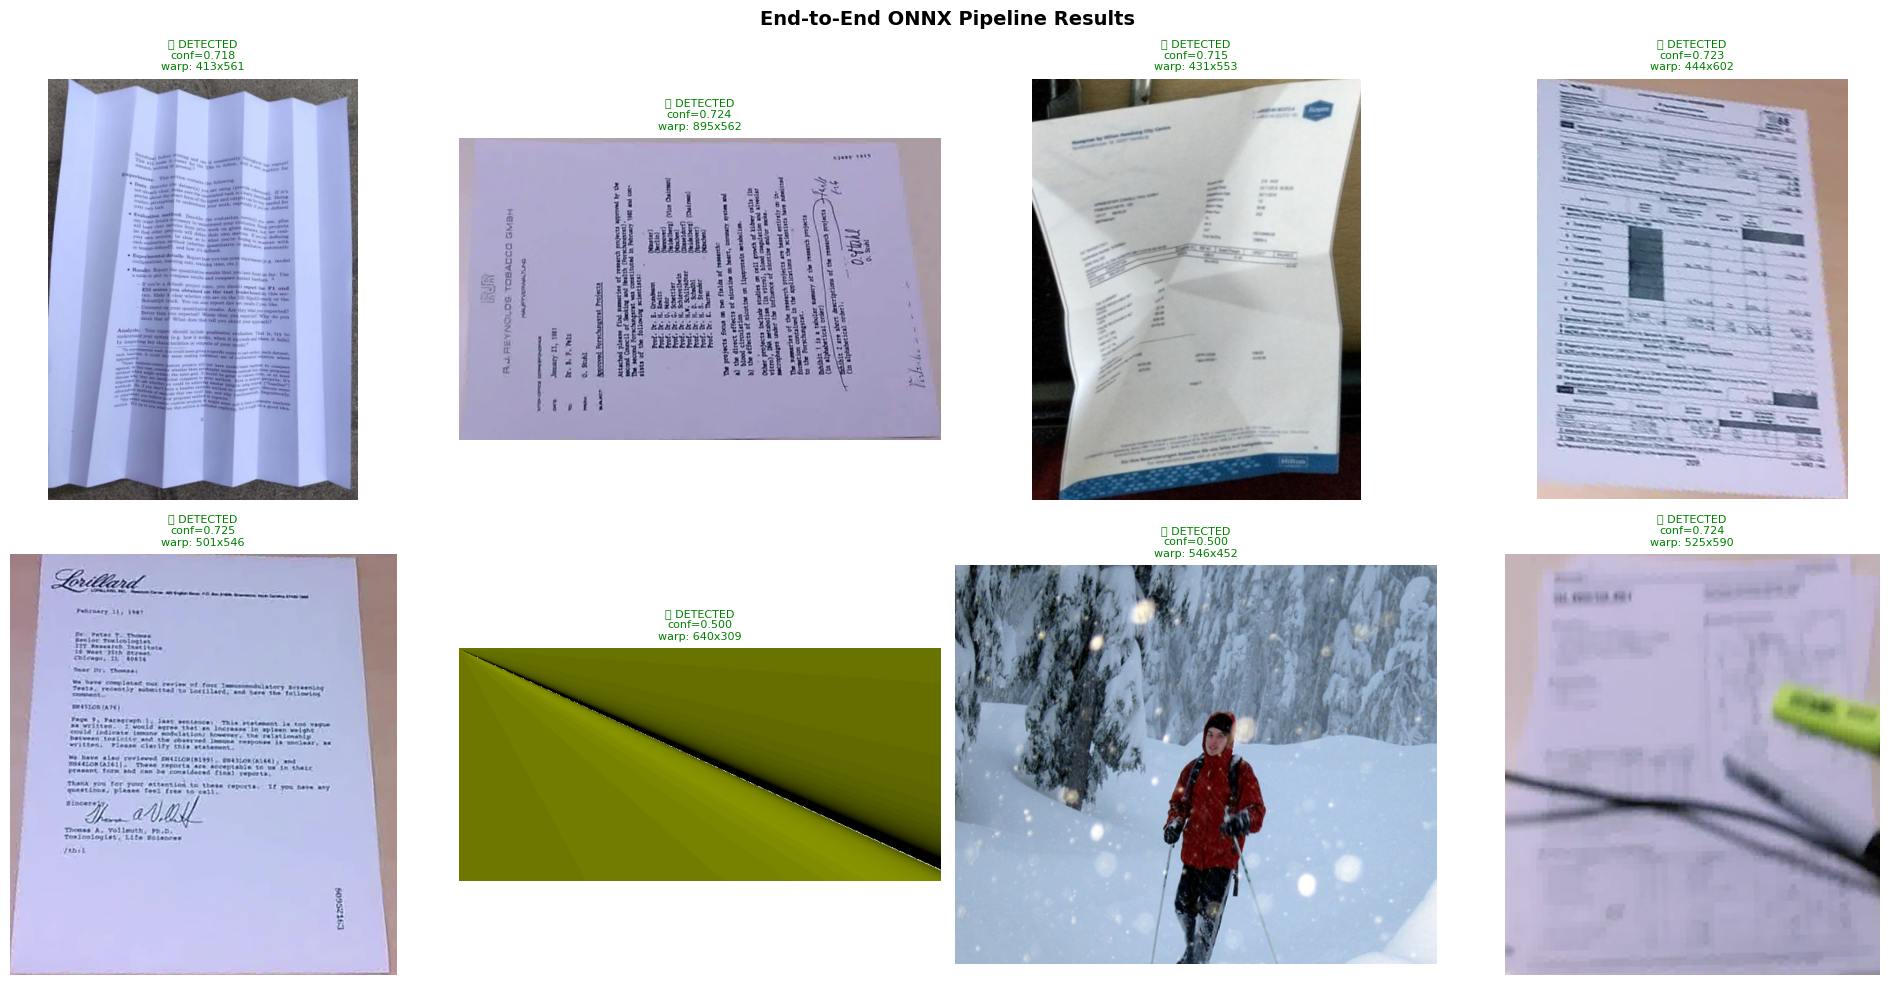

In [18]:
# === Visual Test: Positive & Negative Cases ===

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Ambil campuran positive dan negative
test_samples = random.sample(test_images, min(8, len(test_images)))

for ax, img_path in zip(axes.flat, test_samples):
    img = cv2.imread(str(img_path))
    result = detector.detect(img)

    if result['detected']:
        # Tampilkan warped result
        warped_rgb = cv2.cvtColor(result['warped_image'], cv2.COLOR_BGR2RGB)
        ax.imshow(warped_rgb)
        ax.set_title(
            f"✅ DETECTED\nconf={result['confidence']:.3f}\n"
            f"warp: {result['warped_image'].shape[1]}x{result['warped_image'].shape[0]}",
            fontsize=8, color='green'
        )
    else:
        # Tampilkan original
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
        ax.set_title(f"❌ NO DOCUMENT\n{img_path.name}", fontsize=8, color='red')

    ax.axis('off')

plt.suptitle('End-to-End ONNX Pipeline Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

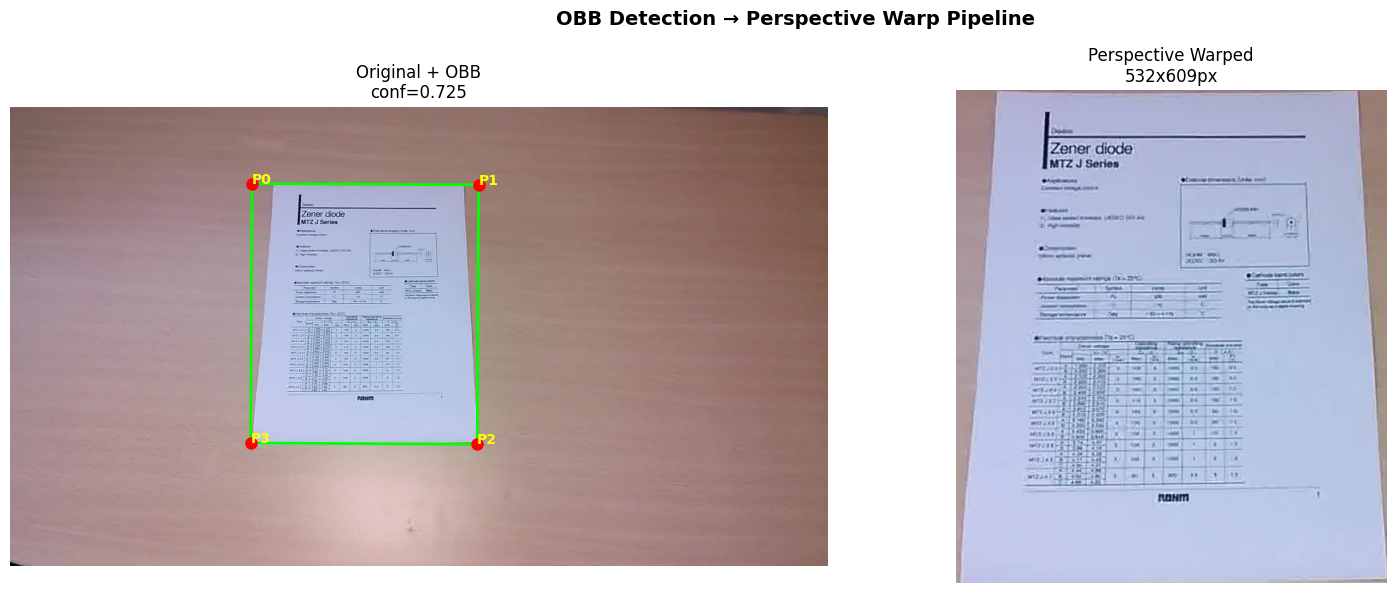

In [19]:
# === Detail View: OBB on Original + Warped Side-by-Side ===

# Cari satu positive sample
for img_path in random.sample(test_images, len(test_images)):
    img = cv2.imread(str(img_path))
    result = detector.detect(img)
    if result['detected']:
        break

if result['detected']:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Left: Original with OBB overlay
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    corners = result['corners_original']
    ordered = DocumentDetectorONNX.order_corners(corners.astype(np.float32))

    ax1.imshow(img_rgb)
    polygon = plt.Polygon(ordered, fill=False, edgecolor='lime', linewidth=2)
    ax1.add_patch(polygon)
    for i, (x, y) in enumerate(ordered):
        ax1.plot(x, y, 'ro', markersize=8)
        ax1.annotate(f'P{i}', (x, y), fontsize=10, color='yellow', fontweight='bold')
    ax1.set_title(f'Original + OBB\nconf={result["confidence"]:.3f}', fontsize=12)
    ax1.axis('off')

    # Right: Warped result
    warped_rgb = cv2.cvtColor(result['warped_image'], cv2.COLOR_BGR2RGB)
    ax2.imshow(warped_rgb)
    ax2.set_title(f'Perspective Warped\n{warped_rgb.shape[1]}x{warped_rgb.shape[0]}px', fontsize=12)
    ax2.axis('off')

    plt.suptitle('OBB Detection → Perspective Warp Pipeline', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada positive detection di sample yang diambil.")

In [20]:
# === Final Summary ===

print("\n" + "=" * 60)
print("📋 MODEL 1 (YOLO11n-OBB) TRAINING SUMMARY")
print("=" * 60)
print(f"\n  Weights (PyTorch): {best_pt}")
print(f"  Weights (ONNX):    {onnx_path}")
print(f"  ONNX Size:         {os.path.getsize(onnx_path) / 1e6:.2f} MB")
print(f"  Input:             {IMGSZ}x{IMGSZ} RGB")
print(f"  Output:            (1, 6, 8400) → transpose → (8400, 6) [cx, cy, w, h, angle, logit] + sigmoid + rotated NMS")
print(f"  Inference (CPU):   ~{times_ms.mean():.0f} ms")
print(f"\n  Val mAP50:         {val_metrics.box.map50:.4f}")
print(f"  Test mAP50:        {test_metrics.box.map50:.4f}")
print(f"\n  Pipeline Chain:")
print(f"    Image → YOLO OBB → Detected?")
print(f"    ├─ No  → return {{'detected': False}}")
print(f"    └─ Yes → Warp + CLAHE → Model 2 (MobileNetV3 Classification)")
print("\n" + "=" * 60)



📋 MODEL 1 (YOLO11n-OBB) TRAINING SUMMARY

  Weights (PyTorch): runs/model1_yolo/document_detector/weights/best.pt
  Weights (ONNX):    runs/model1_yolo/document_detector/weights/best.onnx
  ONNX Size:         10.83 MB
  Input:             640x640 RGB
  Output:            (1, 6, 8400) → transpose → (8400, 6) [cx, cy, w, h, angle, logit] + sigmoid + rotated NMS
  Inference (CPU):   ~30703 ms

  Val mAP50:         0.9947
  Test mAP50:        0.9950

  Pipeline Chain:
    Image → YOLO OBB → Detected?
    ├─ No  → return {'detected': False}
    └─ Yes → Warp + CLAHE → Model 2 (MobileNetV3 Classification)

